In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import math
from tqdm import tqdm
from scipy.spatial import distance
import seaborn as sns
from scipy.linalg import hadamard
from sklearn.metrics import r2_score
import pandas as pd
import datetime
import time
import string

In [2]:
# converts an index to a Hamming graph position
def ind2sub(ind,K,L):
    if ind == 0:
        return np.zeros(L, dtype=int)
    else:
        mysub = int(np.base_repr(ind,K))
        digits = int(math.log10(mysub))+1
        mysub_str = '0'*(L-digits) + str(mysub)
        unjoined = list(mysub_str)
        return np.array([int(i) for i in unjoined])

# converts a Hamming graph position to an index
def sub2ind(sub,K,L):
    return int(sum(np.multiply(sub,[K**(L-i-1) for i in range(L)])))

## Load entire COVID sequence data, remove sequences with no time stamp

In [3]:
df = pd.read_csv('./covid_data/rbd_df.csv')

In [4]:
df

,seq,date,n_mutations
0,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,2019-12-30,0
1,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,2020-12-23,1
2,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,2021-01-30,1
3,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,2021-02-24,1
4,NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFST...,2021-02-26,1
...,...,...,...
11980880,NITNLCPFDEVFNATKFASVYAWNRKRISNCVADYSVLYNLAPFFT...,2022-01-19,16
11980881,NITNLCPFDEVFNATRFASVYAWNRKRISNCVADYSVLYNLAPFFT...,2022-01-19,15
11980882,NITNLCPFDEVFNATRFASVYAWNRKRISNCVADYSVLYNLAPFFT...,2022-01-20,15
11980883,NITNLCPFDEVFNATKFASVYAWNRKRISNCVADYSVLYNLAPFFT...,2022-01-20,16


In [5]:
df['seq'][0] == 'NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKST'

True

In [6]:
# all_timestamps = np.zeros((len(df)))
# for i in tqdm(range(len(df))):
#     try:
#         my_date = datetime.datetime.strptime(df['date'][i],"%Y-%m-%d")
#         my_time = time.mktime(my_date.timetuple())

#         all_timestamps[i] = my_time
#     except:
#         all_timestamps[i] = -1

# get timestamps (-1 means there was an error with the timestamp)
with open('covid_data/all_timestamps.pkl','rb') as file:
    all_timestamps = pickle.load(file)
# number of invalid timestamps
len(np.where(all_timestamps == -1)[0])

242331

In [7]:
# remove sequences with invalid timestamps
indices_to_remove = np.where(all_timestamps == -1)[0]
processed_sequences = np.delete(df['seq'].to_numpy(),indices_to_remove)
processed_timestamps = np.delete(all_timestamps,indices_to_remove)
N_processed_seqs = len(processed_sequences)

### Import fitness effect data to find out which sites have fitness effect data

In [8]:
spike_fitness_effects = pd.read_csv('./covid_data/spike_mutations_and_FEs_malthusian.csv')

In [9]:
wt_seq = 'NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKST'
# get all mutations that fall within the correct range of residues
# [original residue position] - 331 = correct index within WT sequence
all_mutation_list = spike_fitness_effects['mutation'].to_numpy()
starting_aa = [i[0] for i in spike_fitness_effects['mutation'].to_numpy()]
mutated_aa = [i[-1] for i in spike_fitness_effects['mutation'].to_numpy()]
mutation_indices = np.array([i[1:-1] for i in spike_fitness_effects['mutation'].to_numpy()],dtype=int)
mutation_indices -= 331

fitness_effects = spike_fitness_effects['FE'].to_numpy()

In [10]:
finalized_mutation_indices = np.delete(mutation_indices,np.where(mutation_indices < 0)[0])
finalized_starting_aa = np.delete(starting_aa,np.where(mutation_indices < 0)[0])
finalized_mutated_aa = np.delete(mutated_aa,np.where(mutation_indices < 0)[0])
finalized_fitness_effects = np.delete(fitness_effects,np.where(mutation_indices < 0)[0])

finalized_starting_aa = np.delete(finalized_starting_aa,np.where(finalized_mutation_indices > 200)[0])
finalized_mutated_aa = np.delete(finalized_mutated_aa,np.where(finalized_mutation_indices > 200)[0])
finalized_mutation_indices = np.delete(finalized_mutation_indices,np.where(finalized_mutation_indices > 200)[0])
finalized_fitness_effects = np.delete(finalized_fitness_effects,np.where(finalized_mutation_indices > 200)[0])

In [11]:
finalized_mutation_indices.shape

(90,)

In [12]:
print(len(finalized_mutation_indices)) # number of total mutated sites
print(len(np.unique(finalized_mutation_indices))) # number of unique mutated sites
mutation_sites_with_data_available = np.unique(finalized_mutation_indices)

90
52


In [13]:
# make a dictionary of all sites and which mutations are available in the fitness effect dataset
keys_fe_dict = np.unique(finalized_mutation_indices)
values_fe_dict = []
for i in range(len(keys_fe_dict)):
    starting_aa = wt_seq[keys_fe_dict[i]]
    mutant_aa_available = list(finalized_mutated_aa[np.where(finalized_mutation_indices == keys_fe_dict[i])[0]])
    mutant_aa_available.append(starting_aa)
    values_fe_dict.append(mutant_aa_available)
fe_available_aa_dict = dict(zip(keys_fe_dict,values_fe_dict))

In [14]:
# reduced_sequences = []
# for i in tqdm(range(N_processed_seqs)):
#     reduced_sequences.append(np.array(''.join([processed_sequences[i][j] for j in mutation_sites_with_data_available])))
# reduced_sequences = np.array(reduced_sequences)

In [15]:
# processed_sequences = reduced_sequences

In [16]:
temp = np.array(list(wt_seq))
temp[np.delete(np.arange(len(wt_seq)),finalized_mutation_indices)] = 'X'
wt_seq = ''.join(temp)
for i in tqdm(range(N_processed_seqs)):
    temp = np.array(list(processed_sequences[i]))
    temp[np.delete(np.arange(len(wt_seq)),finalized_mutation_indices)] = 'X'
    processed_sequences[i] = ''.join(temp)

100%|██████████| 11738554/11738554 [09:10<00:00, 21330.59it/s]


In [17]:
with open('covid_data/covid_all_seq_processed_sequences_combined_BACKUP.pkl', 'wb') as file:
    pickle.dump(processed_sequences,file)
with open('covid_data/covid_all_seq_processed_timestamps_combined_BACKUP.pkl', 'wb') as file:
    pickle.dump(processed_timestamps,file)

# with open('covid_data/covid_all_seq_processed_sequences_combined_BACKUP.pkl', 'rb') as file:
#     processed_sequences = pickle.load(file)
# with open('covid_data/covid_all_seq_processed_timestamps_combined_BACKUP.pkl', 'rb') as file:
#     processed_timestamps = pickle.load(file)

In [18]:
# get all unique sequences
unique_seqs = np.unique(processed_sequences)
N_unique_seqs = len(unique_seqs)

In [19]:
with open('covid_data/covid_all_seq_unique_seqs_combined_BACKUP.pkl','wb') as file:
    pickle.dump(unique_seqs,file)

In [20]:
# make a dictionary to get the unique sequence index from the sequence itself
seq_dict = dict(zip(list(unique_seqs),list(np.arange(N_unique_seqs,dtype=int))))

In [21]:
start_time = np.min(processed_timestamps)
end_time = np.max(processed_timestamps)
N_timeblocks = 300
delta_t = (end_time - start_time) / N_timeblocks

ft_matrix = np.zeros((N_unique_seqs, N_timeblocks))
for i in tqdm(range(N_processed_seqs)):
    my_time = processed_timestamps[i]
    my_ind = seq_dict[processed_sequences[i]]

    time_index = np.array(np.floor((my_time - start_time) / delta_t),dtype=int)
    if time_index == N_timeblocks:
        time_index = N_timeblocks - 1
    
    ft_matrix[my_ind, time_index] += 1

100%|██████████| 11738554/11738554 [00:22<00:00, 515532.51it/s]


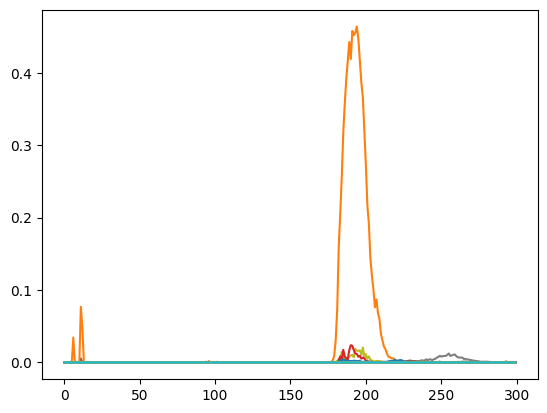

In [22]:
normalized_freq_time = ft_matrix / np.sum(ft_matrix, axis=0)
plt.plot(normalized_freq_time[:2000,:].T)
plt.show()

/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8445/681740590.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(np.arange(len(normalized_freq_time))),np.flip(np.log10(np.sort(np.mean(normalized_freq_time,1)))))
/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8445/681740590.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.scatter(np.log10(np.arange(len(normalized_freq_time))),np.flip(np.log10(np.sort(np.max(normalized_freq_time,1)))))


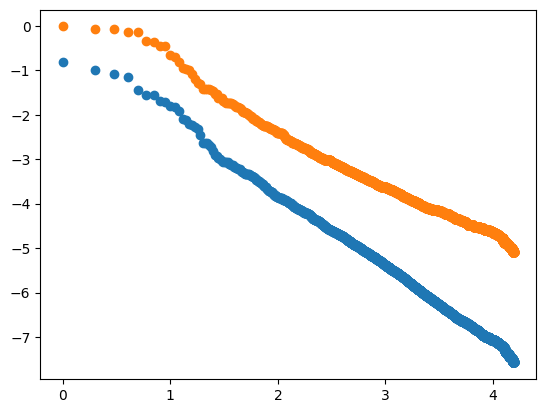

In [23]:
plt.scatter(np.log10(np.arange(len(normalized_freq_time))),np.flip(np.log10(np.sort(np.mean(normalized_freq_time,1)))))
plt.scatter(np.log10(np.arange(len(normalized_freq_time))),np.flip(np.log10(np.sort(np.max(normalized_freq_time,1)))))


In [24]:
np.log10(np.arange(len(normalized_freq_time)))

/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8445/2385946250.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(np.arange(len(normalized_freq_time)))


array([      -inf, 0.        , 0.30103   , ..., 4.19161866, 4.1916466 ,
       4.19167453])

(array([7.035e+03, 6.174e+03, 1.516e+03, 5.070e+02, 1.980e+02, 6.200e+01,
        3.100e+01, 1.000e+01, 6.000e+00, 1.000e+01]),
 array([-5.09590824, -4.58631742, -4.0767266 , -3.56713577, -3.05754495,
        -2.54795412, -2.0383633 , -1.52877247, -1.01918165, -0.50959082,
         0.        ]),
 <BarContainer object of 10 artists>)

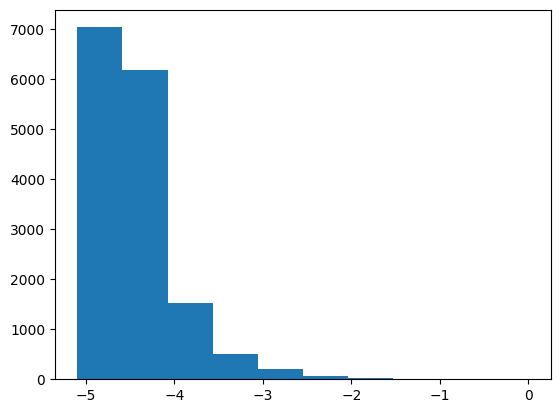

In [25]:
plt.hist(np.log10(np.sort(np.max(normalized_freq_time[np.max(normalized_freq_time,1) > 1e-6],1))))

In [26]:
# number of unique sequence lengths
# seq_lengths = []
# for i in range(N_unique_seqs):
#     seq_lengths.append(len(unique_seqs[i]))
# seq_lengths = set(seq_lengths)

In [27]:
T = N_timeblocks
freq_timeseries = normalized_freq_time
with open('covid_data/covid_all_ts_' + str(T) + '.pkl','wb') as file:
    pickle.dump(freq_timeseries,file)

## Load COVID timeseries

In [28]:
T = N_timeblocks
rare_cutoff_freq = 10**(-6)

In [29]:
# with open('covid_data/covid_ts_' + str(T) + '.pkl','rb') as file:
#     freq_timeseries = pickle.load(file)
freq_timeseries.shape

(15549, 300)

In [79]:
## truncate frequency time series
T_cutoff = 300
freq_timeseries = freq_timeseries[:,:T_cutoff]
T = freq_timeseries.shape[1]

In [80]:
# plt.plot(freq_timeseries.T)
# plt.show()

In [81]:
covid_avg_freqs = np.mean(freq_timeseries,1)
covid_observed_indices = np.where(np.mean(freq_timeseries,1) > rare_cutoff_freq)[0]
peak_frequencies = np.max(freq_timeseries,1)
# covid_observed_indices = np.where(peak_frequencies > rare_cutoff_freq)[0]

N_observed = len(covid_observed_indices)

with open('covid_data/covid_all_seq_observed_indices.pkl','wb') as file:
    pickle.dump(covid_observed_indices,file)

/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8445/1850100196.py:1: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(np.arange(len(covid_avg_freqs)))/np.log(10),np.flip(np.sort(np.log(covid_avg_freqs)/np.log(10))))
/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8445/1850100196.py:2: RuntimeWarning: divide by zero encountered in log
  plt.scatter(np.log(np.arange(len(covid_avg_freqs)))/np.log(10),np.flip(np.sort(np.log(peak_frequencies)/np.log(10))))


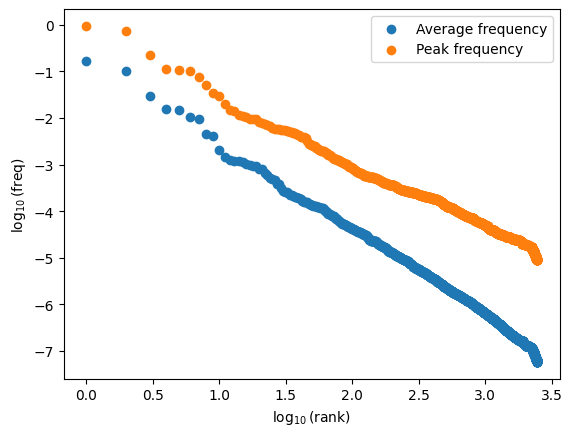

In [82]:
plt.scatter(np.log(np.arange(len(covid_avg_freqs)))/np.log(10),np.flip(np.sort(np.log(covid_avg_freqs)/np.log(10))))
plt.scatter(np.log(np.arange(len(covid_avg_freqs)))/np.log(10),np.flip(np.sort(np.log(peak_frequencies)/np.log(10))))
plt.xlabel('$\log_{10}$(rank)')
plt.ylabel('$\log_{10}$(freq)')
# plt.title('Average Frequencies')
plt.legend(['Average frequency','Peak frequency'])
plt.show()


In [83]:
print('average',freq_timeseries[covid_avg_freqs > rare_cutoff_freq,:].shape)
print('peak',freq_timeseries[peak_frequencies > rare_cutoff_freq,:].shape)

observed_freq_timeseries = freq_timeseries[covid_observed_indices,:]
np.savetxt('covid_data/covid_freq_timeseries_T' + str(freq_timeseries.shape[1]) + '.csv',observed_freq_timeseries,delimiter=',')

average (816, 150)
peak (2458, 150)


## Make mutation matrix for observed sequences (assumes uniform amino acid substitution rates)

In [35]:
# K = 2
# L = 15

In [36]:
# covid_M = np.zeros((N_observed,N_observed))
# for i in tqdm(range(N_observed)):
#     for j in range(N_observed):
#         seq_i = np.array(list(unique_seqs[covid_observed_indices[i]]))
#         seq_j = np.array(list(unique_seqs[covid_observed_indices[j]]))
#         d = round(distance.hamming(seq_i, seq_j) * len(seq_i))
#         if d == 1:
#             covid_M == 1

In [37]:
# covid_M_normalized = covid_M - 201*np.eye(N_observed)
# # covid_M_normalized = covid_M - np.sum(covid_M,1)

In [38]:
# np.savetxt('covid_data/covid_M.csv',covid_M_normalized,delimiter=',')

In [39]:
wt_seq

'XXXXXXXXGEXXXAXRXXXXXAXXXKRXXXXXXXXXXXXNSXSXSTXXXXXXXPTXXXXXXXXNXXXXXXXXRXDXXRXXAXXQTXKXXXXXXXXXXXXXXXXXXXXXNNXXXKVGXXYNXLYXXXXKSNXXXXXXXXXTXXXXXXSTPXNXVEXFXXXFXXQSXGXQPXNXXXYXXXXXXXXXXXXXXAXAXXXXXXXXX'

In [40]:
finalized_mutation_indices

array([ 13,  21,  80, 189, 191, 191,  74,   9, 153, 153, 153, 153, 153,
       155, 155, 155, 155, 155, 159, 159, 159,   8,   8,   8, 115, 115,
       115, 115, 165,  25,  86,  86, 113, 113, 113, 113, 127, 121, 121,
       121,  39,  63, 108, 109, 109, 119, 119, 129, 150, 170, 170, 170,
        53, 148, 168,  83, 162, 162, 167,  15,  15,  15,  15,  26,  72,
        77,  40,  40,  40,  42,  44, 128, 146, 146, 146, 163,  45,  54,
        84, 139, 147, 147, 147, 114, 114, 152, 118, 118, 122, 174])

In [41]:
len(unique_seqs[covid_observed_indices][0])

201

## Make real fitness vector for observed variants

In [43]:
indices_with_known_mutation_effects = np.unique(finalized_mutation_indices)
wt_outside = np.delete(np.array(list(wt_seq)),indices_with_known_mutation_effects)
wt_at_mutation_sites = np.array(list(wt_seq))[indices_with_known_mutation_effects]
fitness_list = np.zeros((len(unique_seqs[covid_observed_indices])))

# go through each of the unique sequences represented in the time window
for i in tqdm(range(len(fitness_list))):
    # for each sequence, separate the sites whose mutation effects are known
    seq = np.array(list(unique_seqs[covid_observed_indices][i]))
    chars_at_mutation_sites = seq[indices_with_known_mutation_effects]
    chars_outside_mutation_sites = np.delete(seq,indices_with_known_mutation_effects)
    # print(chars_at_mutation_sites)
    # if the characters outside the region don't completely match WT, cannot predict the fitness
    if (chars_outside_mutation_sites == wt_outside).all():
        # if they the outside characters match WT, check the sites which are known 
        # if the known sites' AAs do match the WT, 0 fitness effect
        for j in range(len(indices_with_known_mutation_effects)):
            # if the characters do not match WT, first check if they are part of the known substitution list (if not, set to nan)
            if chars_at_mutation_sites[j] != wt_at_mutation_sites[j]:
                indices_of_mutant_aa = np.where(finalized_mutation_indices == indices_with_known_mutation_effects[j])[0]
                subset_mutated_aa = finalized_mutated_aa[indices_of_mutant_aa]
                if np.isin(chars_at_mutation_sites[j],subset_mutated_aa):
                    subset_mutated_fe = finalized_fitness_effects[indices_of_mutant_aa]
                    fitness_list[i]  += subset_mutated_fe[np.where(subset_mutated_aa == chars_at_mutation_sites[j])[0]]
                else:
                    fitness_list[i] = np.nan
    else:
        fitness_list[i] = np.nan

  0%|          | 0/2193 [00:00<?, ?it/s]/var/folders/b3/fl_61b2j691_6q8dl5r_ry3m0000gn/T/ipykernel_8445/2627788620.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  fitness_list[i]  += subset_mutated_fe[np.where(subset_mutated_aa == chars_at_mutation_sites[j])[0]]
100%|██████████| 2193/2193 [00:00<00:00, 5229.96it/s]


In [62]:
chars_at_mutation_sites[j]

'A'

(array([319., 464., 214.,  41.,  61., 229., 176.,  23.,   6.,   2.]),
 array([-0.00306621,  0.00876588,  0.02059796,  0.03243004,  0.04426212,
         0.0560942 ,  0.06792628,  0.07975836,  0.09159044,  0.10342252,
         0.1152546 ]),
 <BarContainer object of 10 artists>)

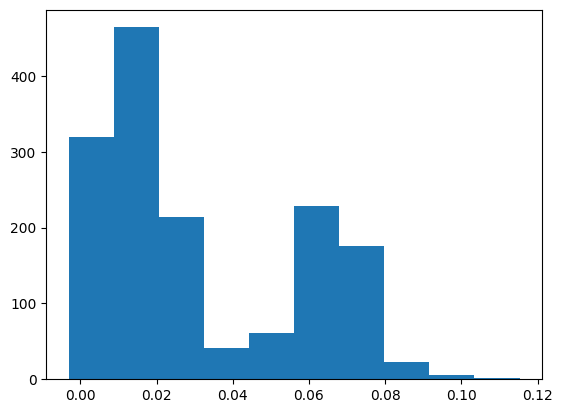

In [73]:
plt.hist(fitness_list)

In [64]:
np.savetxt('covid_data/covid_F_real.csv',fitness_list,delimiter=',')

## Make mutation matrix for observed sequences

In [65]:
K = 2
L = 15

In [66]:
# wt_seq = 'NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKST'
mutated_sites = np.array([339, 371, 373, 375, 417, 440, 446, 477, 478, 484, 493, 496, 498, 501, 505],dtype=int)
mutated_indices = np.array(mutated_sites - 331*np.ones((L)),dtype=int)

wt_subset = [wt_seq[i] for i in mutated_indices]
omicron_subset = ['D', 'L', 'P', 'F', 'N', 'K', 'S', 'N', 'K', 'A', 'R', 'S', 'R', 'Y', 'H']

In [67]:
genetic_code_dict = {}
genetic_code_dict['F'] = ['UUU','UUC']
genetic_code_dict['L'] = ['UUA','UUG','CUU','CUC','CUA','CUG']
genetic_code_dict['S'] = ['UCU','UCC','UCA','UCG','AGU','AGC']
genetic_code_dict['Y'] = ['UAU','UAC']
genetic_code_dict['X'] = ['UAA','UAG','UGA']
genetic_code_dict['C'] = ['UGU','UGC']
genetic_code_dict['W'] = ['UGG']
genetic_code_dict['P'] = ['CCU','CCC','CCA','CCG']
genetic_code_dict['H'] = ['CAU','CAC']
genetic_code_dict['Q'] = ['CAG','CAA']
genetic_code_dict['R'] = ['CGU','CGC','CGA','CGG','AGA','AGG']
genetic_code_dict['I'] = ['AUU','AUC','AUA']
genetic_code_dict['M'] = ['AUG']
genetic_code_dict['T'] = ['ACU','ACC','ACA','ACG']
genetic_code_dict['N'] = ['AAU','AAC']
genetic_code_dict['K'] = ['AAA','AAG']
genetic_code_dict['V'] = ['GUU','GUC','GUA','GUG']
genetic_code_dict['A'] = ['GCU','GCC','GCA','GCG']
genetic_code_dict['D'] = ['GAU','GAC']
genetic_code_dict['E'] = ['GAA','GAG']
genetic_code_dict['G'] = ['GGU','GGC','GGA','GGG']

In [68]:
L = 201
covid_M = np.zeros((N_observed,N_observed))
for i in tqdm(range(N_observed)): # i is the mutated genotype
    for j in range(N_observed): # j is the initial genotype
        seq_i = np.array(list(unique_seqs[covid_observed_indices[i]]))
        seq_j = np.array(list(unique_seqs[covid_observed_indices[j]]))
        d = round(distance.hamming(seq_i, seq_j) * len(seq_i))
        if d == 1:
            diff_index = np.where(seq_i != seq_j)[0][0]
            initial_residue = seq_j[diff_index]
            final_residue = seq_i[diff_index]

            # get codons for initial and final residues
            initial_codons = genetic_code_dict[initial_residue]
            final_codons = genetic_code_dict[final_residue]

            # calculate AA --> AA transition probability
            n_neighbors = 0
            for initial in initial_codons:
                for final in final_codons:
                    d = round(distance.hamming(list(initial), list(final)) * len(initial))
                    if d == 1:
                        n_neighbors += 1
            aa_transition_prob = n_neighbors/(9*len(initial_codons)) # given selection of a site
            transition_prob = aa_transition_prob/L # given a sequence 

            # populate sequence mutation rate matrix
            covid_M[i,j] = transition_prob
        
        if i == j:
            no_mut_prob = 0
            for l in range(L):
                # calculate robustness of the AA at site l
                n_neighbors = 0
                site_codons = genetic_code_dict[seq_j[l]]
                for initial in site_codons:
                    for final in site_codons:
                        d = round(distance.hamming(list(initial), list(final)) * len(initial))
                        if d == 1:
                            n_neighbors += 1
                aa_robustness = n_neighbors/(9*len(site_codons))
                no_mut_prob += aa_robustness/L
            covid_M[i,i] = no_mut_prob - 1

100%|██████████| 2193/2193 [03:35<00:00, 10.19it/s]


In [71]:
covid_M_normalized = covid_M
# # covid_M_normalized = covid_M - np.sum(covid_M,1)
# sns.heatmap(np.log(covid_M_normalized))

In [72]:
np.savetxt('covid_data/covid_M.csv',covid_M_normalized,delimiter=',')